In [1]:
import numpy as np
import pandas as pd

In [2]:
df1 = pd.read_csv('./Flipkart_mobile_brands_scraped_data.csv')
df2 = pd.read_csv('./Flipkart_Mobiles.csv')

In [3]:
df1.shape

(2647, 8)

In [4]:
df2.shape

(3114, 8)

In [5]:
df1.columns

Index(['Brand', 'Model', 'Color', 'Memory', 'Storage', 'Rating',
       'Selling Price', 'Original Price'],
      dtype='object')

In [6]:
df2.columns

Index(['Brand', 'Model', 'Color', 'Memory', 'Storage', 'Rating',
       'Selling Price', 'Original Price'],
      dtype='object')

In [7]:
tot_len = len(df1) + len(df2)
tot_len

5761

In [8]:
df1.head()

,Brand,Model,Color,Memory,Storage,Rating,Selling Price,Original Price
0,OPPO,A53,Moonlight Black,4 GB,64 GB,4.5,11990.0,15990.0
1,OPPO,A53,Mint Cream,4 GB,64 GB,4.5,11990.0,15990.0
2,OPPO,A53,Moonlight Black,6 GB,128 GB,4.3,13990.0,17990.0
3,OPPO,A53,Mint Cream,6 GB,128 GB,4.3,13990.0,17990.0
4,OPPO,A53,Electric Black,4 GB,64 GB,4.5,11990.0,15990.0


In [9]:
df2.head()

,Brand,Model,Color,Memory,Storage,Rating,Selling Price,Original Price
0,OPPO,A53,Moonlight Black,4 GB,64 GB,4.5,11990,15990
1,OPPO,A53,Mint Cream,4 GB,64 GB,4.5,11990,15990
2,OPPO,A53,Moonlight Black,6 GB,128 GB,4.3,13990,17990
3,OPPO,A53,Mint Cream,6 GB,128 GB,4.3,13990,17990
4,OPPO,A53,Electric Black,4 GB,64 GB,4.5,11990,15990


In [10]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2647 entries, 0 to 2646
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Brand           2647 non-null   object 
 1   Model           2645 non-null   object 
 2   Color           2505 non-null   object 
 3   Memory          2605 non-null   object 
 4   Storage         2568 non-null   object 
 5   Rating          2647 non-null   float64
 6   Selling Price   2644 non-null   float64
 7   Original Price  969 non-null    float64
dtypes: float64(3), object(5)
memory usage: 165.6+ KB


In [11]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3114 entries, 0 to 3113
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Brand           3114 non-null   object 
 1   Model           3114 non-null   object 
 2   Color           3114 non-null   object 
 3   Memory          3071 non-null   object 
 4   Storage         3075 non-null   object 
 5   Rating          2970 non-null   float64
 6   Selling Price   3114 non-null   int64  
 7   Original Price  3114 non-null   int64  
dtypes: float64(1), int64(2), object(5)
memory usage: 194.8+ KB


### Let's first convert all the features to same datatypes :

In [12]:
df2['Selling Price'] = df2['Selling Price'].astype('float64')
df2['Original Price'] = df2['Original Price'].astype('float64')

In [13]:
print(df2['Selling Price'].dtype)
print(df2['Original Price'].dtype)

float64
float64


### Let's Combine both datasets :

In [14]:
combined_df = pd.concat([df1,df2], ignore_index = True)
combined_df = combined_df.drop_duplicates()

In [15]:
combined_df

,Brand,Model,Color,Memory,Storage,Rating,Selling Price,Original Price
0,OPPO,A53,Moonlight Black,4 GB,64 GB,4.5,11990.0,15990.0
1,OPPO,A53,Mint Cream,4 GB,64 GB,4.5,11990.0,15990.0
2,OPPO,A53,Moonlight Black,6 GB,128 GB,4.3,13990.0,17990.0
3,OPPO,A53,Mint Cream,6 GB,128 GB,4.3,13990.0,17990.0
4,OPPO,A53,Electric Black,4 GB,64 GB,4.5,11990.0,15990.0
...,...,...,...,...,...,...,...,...
5756,SAMSUNG,M52 5G,Blazing Black,6 GB,128 GB,4.3,25990.0,25990.0
5757,SAMSUNG,M52 5G,Icy Blue,6 GB,128 GB,4.3,25489.0,28449.0
5758,SAMSUNG,M52 5G,Icy Blue,8 GB,128 GB,4.3,27239.0,31489.0
5759,SAMSUNG,M52 5G,Slate Black,8 GB,128 GB,4.2,22989.0,22989.0


In [16]:
# Duplicate entries : 

dup_en = tot_len - len(combined_df)
dup_en

1072

In [17]:
combined_df.isnull().sum()

Brand                0
Model                2
Color              133
Memory              77
Storage             95
Rating             130
Selling Price        3
Original Price    1606
dtype: int64

In [18]:
combined_df[combined_df['Model'].isna()]

,Brand,Model,Color,Memory,Storage,Rating,Selling Price,Original Price
274,Google Pixel,NaN,Quite Black,4 GB,128 GB,4.4,66000.0,NaN
275,Google Pixel,NaN,Very Silver,4 GB,32 GB,4.4,57000.0,NaN


In [19]:
combined_df[combined_df['Selling Price'].isna()]

,Brand,Model,Color,Memory,Storage,Rating,Selling Price,Original Price
128,OPPO,A16,Crystal Black,4 GB,64 GB,0.0,NaN,NaN
420,ASUS,Zenfone Go 5.0,Black,2 GB,8 GB,4.0,NaN,NaN
2426,vivo,Y20G,Obsidian Black,6 GB,128 GB,4.3,NaN,NaN


In [20]:
combined_df[combined_df['Model'] == 'A16']

,Brand,Model,Color,Memory,Storage,Rating,Selling Price,Original Price
37,OPPO,A16,Pearl Blue,4 GB,64 GB,0.0,13850.0,NaN
41,OPPO,A16,CRYSTAL BLACK,4 GB,64 GB,0.0,13990.0,15990.0
128,OPPO,A16,Crystal Black,4 GB,64 GB,0.0,NaN,NaN
2684,OPPO,A16,Pearl Blue,4 GB,64 GB,NaN,13850.0,13850.0
2688,OPPO,A16,CRYSTAL BLACK,4 GB,64 GB,NaN,13990.0,15990.0
2775,OPPO,A16,Crystal Black,4 GB,64 GB,NaN,13490.0,13490.0
5344,OPPO,A16,Blue,3 GB,32 GB,3.7,10490.0,10490.0
5345,OPPO,A16,Black,3 GB,32 GB,3.7,10490.0,10490.0
5346,OPPO,A16,White,3 GB,32 GB,3.7,10490.0,10490.0
5676,OPPO,A16,Royal Gold,4 GB,64 GB,4.3,13490.0,13490.0


In [21]:
combined_df[combined_df['Model'] == 'Zenfone Go 5.0']

,Brand,Model,Color,Memory,Storage,Rating,Selling Price,Original Price


In [22]:
combined_df[combined_df['Model'] == 'Y20G']

,Brand,Model,Color,Memory,Storage,Rating,Selling Price,Original Price


### When the data is scraped from the website, it might contain the Non-Breaking spaces / characters. We need to remove them as : 

In [23]:
combined_df['Model'] = combined_df['Model'].astype(str).str.replace(r'\s+',' ' ,regex = True).str.strip()

In [24]:
combined_df[combined_df['Model'] == 'Zenfone Go 5.0']

,Brand,Model,Color,Memory,Storage,Rating,Selling Price,Original Price
408,ASUS,Zenfone Go 5.0,White,2 GB,16 GB,4.0,6999.0,NaN
420,ASUS,Zenfone Go 5.0,Black,2 GB,8 GB,4.0,NaN,NaN
436,ASUS,Zenfone Go 5.0,Black,2 GB,16 GB,4.0,4499.0,NaN
3055,ASUS,Zenfone Go 5.0,White,2 GB,16 GB,4.0,6999.0,6999.0
3067,ASUS,Zenfone Go 5.0,Black,2 GB,8 GB,4.0,4990.0,4990.0
3083,ASUS,Zenfone Go 5.0,Black,2 GB,16 GB,4.0,4499.0,4499.0


In [25]:
combined_df[combined_df['Model'] == 'Y20G']

,Brand,Model,Color,Memory,Storage,Rating,Selling Price,Original Price
2426,vivo,Y20G,Obsidian Black,6 GB,128 GB,4.3,NaN,NaN
2429,vivo,Y20G,Purist Blue,2 GB,32 GB,4.2,49990.0,54990.0
2446,vivo,Y20G,Obsidian Black,4 GB,64 GB,4.4,23990.0,NaN
2457,vivo,Y20G,Purist Blue,3 GB,16 GB,4.3,18990.0,20990.0
5072,vivo,Y20G,Obsidian Black,6 GB,128 GB,4.3,13400.0,13400.0
5092,vivo,Y20G,Obsidian Black,4 GB,64 GB,4.4,23990.0,23990.0


### The columns "Selling Price" and "Original Price" are crucial for this Analysis. So, Let's Create a function to fill these Null values correctly. Firstly for "Selling Price" as :

In [26]:
def fill_missing_selling_price(df, index):
    if pd.isna(combined_df.at[index, 'Selling Price']):
        target_row = combined_df.loc[index]
    # Create mask for similar rows ( excluding target row itself)
        mask = (
            (combined_df['Brand'] == target_row['Brand']) &
            (combined_df['Model'] == target_row['Model']) &
            (combined_df['Color'] == target_row['Color']) &
            (combined_df['Memory'] == target_row['Memory']) &
            (combined_df['Storage'] == target_row['Storage']) &
            (combined_df.index != index)
        )

        similar_rows = combined_df[mask]

        # If similar rows with valid price found, fill with average or mode.

        valid_prices = similar_rows['Selling Price'].dropna()   # In similar rows found if any nan in Selling Price occures,dropping it.
        if not valid_prices.empty:
            replacement = valid_prices.mean()
            combined_df.at[index, 'Selling Price'] = replacement
            print(f"Filled index {index} with Selling Price {replacement:.2f}")
        else:
            print(f"No Similar rows with valid 'Selling Price' for index {index}")
    else:
        print(f"index {index} already has Selling Price.")
           
             
    
    

In [27]:
fill_missing_selling_price(combined_df,128)

Filled index 128 with Selling Price 13490.00


In [28]:
fill_missing_selling_price(combined_df,420)

Filled index 420 with Selling Price 4990.00


In [29]:
fill_missing_selling_price(combined_df,2426)

Filled index 2426 with Selling Price 13400.00


In [30]:
len(combined_df[combined_df['Selling Price'].isna()])

0

### Selling Price missing values are filled . Now its time for missing values in "Original Price" 

#### As we see many of the rows having Same "Selling Price" and "Original Price", We fill the "Original Price" missing values with their corresponding "Selling Price" as :

In [31]:
combined_df.head(2)

,Brand,Model,Color,Memory,Storage,Rating,Selling Price,Original Price
0,OPPO,A53,Moonlight Black,4 GB,64 GB,4.5,11990.0,15990.0
1,OPPO,A53,Mint Cream,4 GB,64 GB,4.5,11990.0,15990.0


In [32]:
combined_df['Original Price'] = combined_df['Original Price'].fillna(combined_df['Selling Price'])

### Now to fill the remaining missing values in the columns 'Color','Memory','Storage','Rating', We use Fill Forward Method As :

In [33]:
cols = ['Color', 'Memory', 'Storage', 'Rating']
combined_df[cols] = combined_df[cols].ffill()

In [34]:
combined_df.isnull().sum()

Brand             0
Model             0
Color             0
Memory            0
Storage           0
Rating            0
Selling Price     0
Original Price    0
dtype: int64

In [35]:
combined_df

,Brand,Model,Color,Memory,Storage,Rating,Selling Price,Original Price
0,OPPO,A53,Moonlight Black,4 GB,64 GB,4.5,11990.0,15990.0
1,OPPO,A53,Mint Cream,4 GB,64 GB,4.5,11990.0,15990.0
2,OPPO,A53,Moonlight Black,6 GB,128 GB,4.3,13990.0,17990.0
3,OPPO,A53,Mint Cream,6 GB,128 GB,4.3,13990.0,17990.0
4,OPPO,A53,Electric Black,4 GB,64 GB,4.5,11990.0,15990.0
...,...,...,...,...,...,...,...,...
5756,SAMSUNG,M52 5G,Blazing Black,6 GB,128 GB,4.3,25990.0,25990.0
5757,SAMSUNG,M52 5G,Icy Blue,6 GB,128 GB,4.3,25489.0,28449.0
5758,SAMSUNG,M52 5G,Icy Blue,8 GB,128 GB,4.3,27239.0,31489.0
5759,SAMSUNG,M52 5G,Slate Black,8 GB,128 GB,4.2,22989.0,22989.0


In [36]:
print("Minimum Selling Price in Dataset -->",combined_df['Selling Price'].min())

Minimum Selling Price in Dataset --> 1000.0


In [37]:
print("Maximum Selling Price in Dataset-->",combined_df['Selling Price'].max())

Maximum Selling Price in Dataset--> 179900.0


# ==========================================

## Now our Dataset is Ready to be Analize, with the help of some Given Question : 

## Que. 1. WHAT ARE THE DIFFERENT PRICE RANGE SEGMENTS FOR MOBILES IN INDIA ?

### To answer this question, we need to form a new column in our dataset ("Price Range") As :

In [38]:
 # Defining Price bins and labels :

price_bins = [0, 5000, 10000, 15000, 20000, 30000, 50000, 100000, 150000, float('inf')]
price_labels = ['<5k','5k-10k','10k-15k','15k-20k','20k-30k','30k-50k','50k-100k','100k-150k','>150k']

# Creating a new column in original dataset as :

combined_df['Price Segment'] = pd.cut(combined_df['Selling Price'], bins = price_bins, labels = price_labels)

In [39]:
combined_df.head(2)

,Brand,Model,Color,Memory,Storage,Rating,Selling Price,Original Price,Price Segment
0,OPPO,A53,Moonlight Black,4 GB,64 GB,4.5,11990.0,15990.0,10k-15k
1,OPPO,A53,Mint Cream,4 GB,64 GB,4.5,11990.0,15990.0,10k-15k


In [40]:
# Now To visualize the results we need to import some visualization library of python As :

import seaborn as sns
import matplotlib.pyplot as plt

In [41]:
segments_count = combined_df['Price Segment'].value_counts().sort_index()

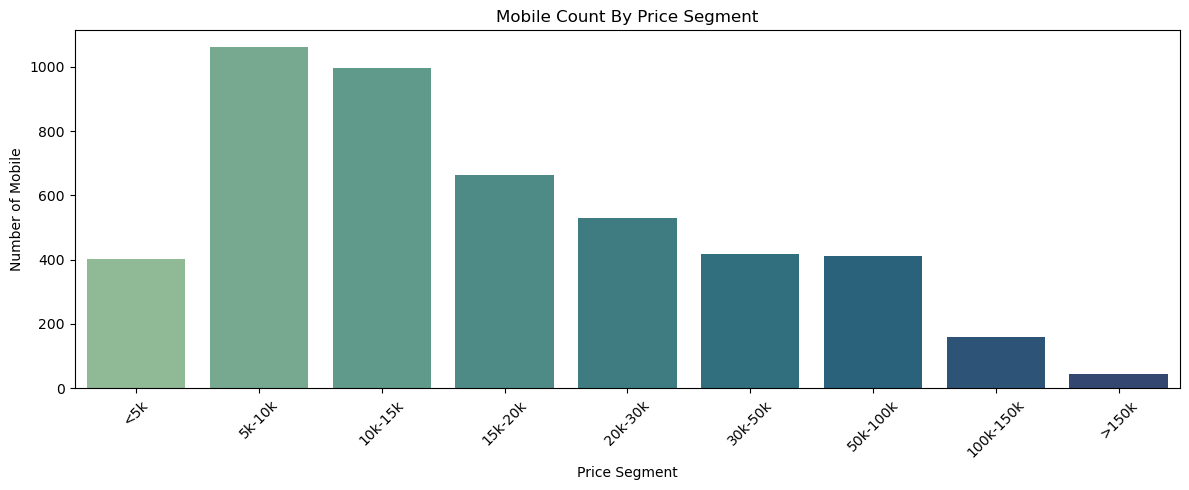

In [42]:
plt.figure(figsize = (12,5))
sns.barplot(x = segments_count.index, y = segments_count.values, hue = segments_count.index, palette = 'crest')
plt.title("Mobile Count By Price Segment")
plt.xlabel("Price Segment")
plt.ylabel("Number of Mobile")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

# Above Barplot shows the Different Price Segments For Mobile in India 

# ========================================

## Que. 2. Which Brand Provides the Most Product Offerings in the Indian Market ?

In [43]:
# Count how many products each brand offers, as :

brand_counts = combined_df['Brand'].value_counts()

# Displaying the top Brands :

print("Product Offerings By Brands")
print(brand_counts)

Product Offerings By Brands
Brand
SAMSUNG         1157
Apple            537
realme           433
OPPO             378
Nokia            364
Xiaomi           299
GIONEE           235
Lenovo           225
ASUS             221
LG               178
Motorola         160
vivo             155
Infinix          150
POCO              75
HTC               60
Google Pixel      57
IQOO               5
Name: count, dtype: int64


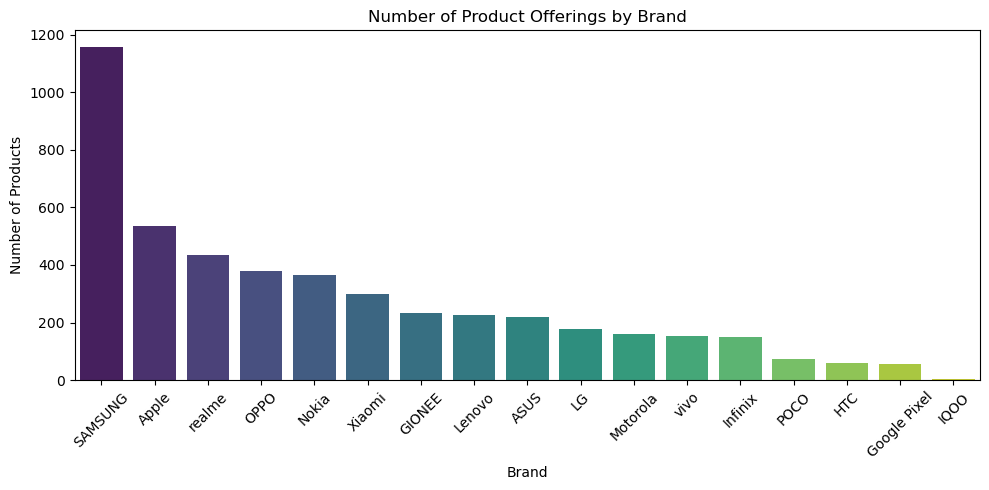

In [44]:
plt.figure(figsize=(10, 5))
sns.barplot(x=brand_counts.index, y=brand_counts.values, hue = brand_counts.index, palette='viridis')

plt.title('Number of Product Offerings by Brand')
plt.xlabel('Brand')
plt.ylabel('Number of Products')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Above Barplot shows That "SAMSUNG","Apple","realme","OPPO","Nokia", etc are the top Brands that Provide the Most Product Offerings in Indian Market. 

# =================================================

## Que.3. Which Brand caters to all different segments ? (low range, mid range, premium)

In [45]:
# defining a Function to classify the price range ,as :

def classify_segment(price):
    if price < 10000:
        return 'Low Range'
    elif price <= 30000:
        return 'Mid Range'
    else:
        return 'Premium'

In [46]:
# Creating a new column with segment classification :

combined_df['Segments'] = combined_df['Selling Price'].apply(classify_segment)

In [47]:
# Group by Brand and find unique segments per brand :

brand_segments = combined_df.groupby('Brand')['Segments'].nunique()

# Filtering brands that cover all 3 segments

brands_in_all_segments = brand_segments[brand_segments == 3].index.tolist()

# Printing the results : 

print(" Brands that caters to all segments (Low range, Mid range & Premium):")
print(brands_in_all_segments)

 Brands that caters to all segments (Low range, Mid range & Premium):
['ASUS', 'HTC', 'LG', 'Motorola', 'Nokia', 'OPPO', 'POCO', 'SAMSUNG', 'Xiaomi', 'realme', 'vivo']


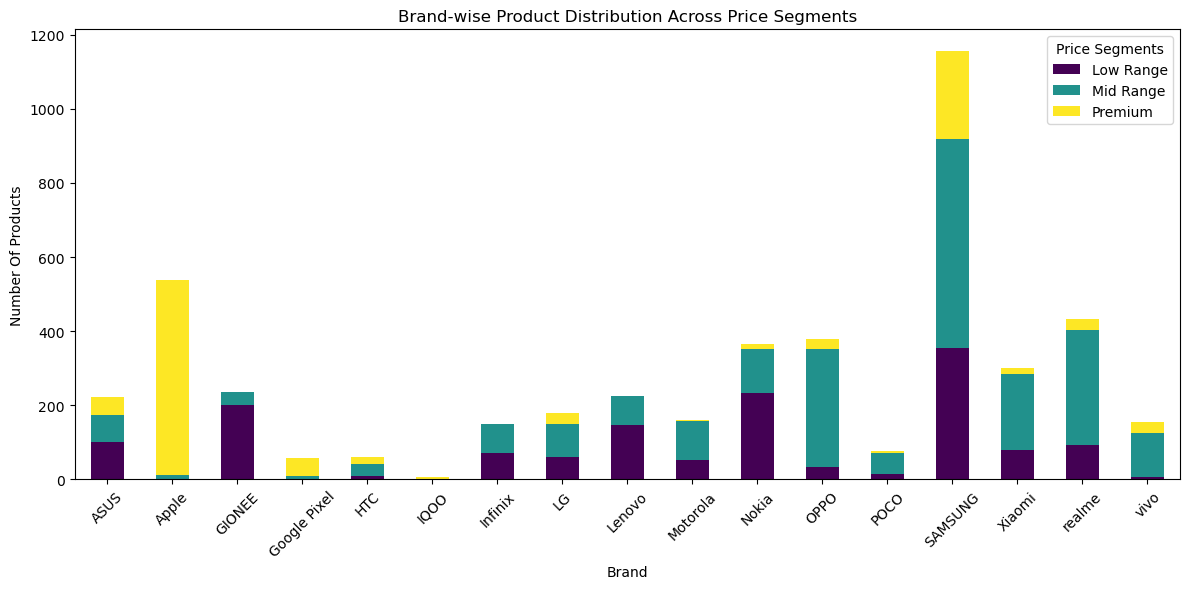

In [48]:
# Lets Try to Visualize it as :

# Creating the segment distribution table as :

segment_distribution = combined_df.groupby(['Brand', 'Segments']).size().unstack().fillna(0)

# Plotting as :

segment_distribution.plot(kind = 'bar', stacked = True, figsize = (12,6), colormap = 'viridis')
plt.title("Brand-wise Product Distribution Across Price Segments")
plt.xlabel("Brand")
plt.ylabel("Number Of Products")
plt.legend(title = 'Price Segments')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()                                 

## Above plot shows that 'ASUS', 'HTC', 'LG', 'Motorola', 'Nokia', 'OPPO', 'POCO', 'SAMSUNG', 'Xiaomi', 'realme', 'vivo' these are the Brands Caters to all the different Segments.

# ==============================================

# Que.4. What Specifications are the Most Common that are Offered by Various Brands

In [49]:
combined_df.head(2)

,Brand,Model,Color,Memory,Storage,Rating,Selling Price,Original Price,Price Segment,Segments
0,OPPO,A53,Moonlight Black,4 GB,64 GB,4.5,11990.0,15990.0,10k-15k,Mid Range
1,OPPO,A53,Mint Cream,4 GB,64 GB,4.5,11990.0,15990.0,10k-15k,Mid Range


### Here in the Given Dataset, the Specifications are "Color","Memory","Storage". So, Lets try to find Most common Specifications As : 

In [50]:
# Top 5 Most Common "Color" Specification :

print("Top Color Variants:")
print(combined_df['Color'].value_counts().head())

# Top 5 Most Common "Memory" Specification :

print("Top Memory Variants:")
print(combined_df['Memory'].value_counts().head())

# Top 5 Most Common "Storage" Specification :

print("Top Storage Variants:")
print(combined_df['Storage'].value_counts().head())



Top Color Variants:
Color
Black     725
Gold      343
White     275
Blue      232
Silver    175
Name: count, dtype: int64
Top Memory Variants:
Memory
4 GB    1132
3 GB     802
6 GB     697
2 GB     637
8 GB     438
Name: count, dtype: int64
Top Storage Variants:
Storage
64 GB     1166
128 GB    1011
32 GB      880
16 GB      564
256 GB     319
Name: count, dtype: int64


### Above output Shows the Most common Specification Offered by Various Brands.

# ===========================================

# Que.5. Provide More Detailed Insights based on data provided

#### 1) Price vs Rating Analysis

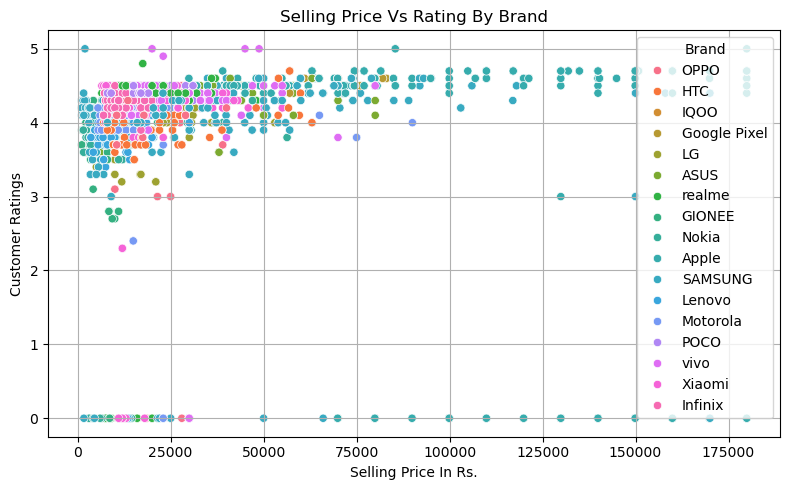

In [51]:
# Do expensive mobiles actually get better ratings? Let's See :

plt.figure(figsize = (8, 5))
sns.scatterplot(data = combined_df, x = 'Selling Price', y = 'Rating', hue = 'Brand')
plt.title("Selling Price Vs Rating By Brand")
plt.xlabel('Selling Price In Rs.')
plt.ylabel('Customer Ratings')
plt.grid(True)
plt. tight_layout()
plt.show()

### Under Rs.75000/- we have more number of rating given and maximum are between 4 to 5.

#### -----------------------------------

#### 2) Most Competetive Segment :

C:\Users\dhira\AppData\Local\Temp\ipykernel_19116\2061687691.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_brand_counts = combined_df.groupby('Price Segment')['Brand'].nunique().sort_values(ascending=False)


Price Segment
10k-15k      15
20k-30k      15
5k-10k       14
15k-20k      14
30k-50k      13
50k-100k     11
<5k           7
100k-150k     2
>150k         2
Name: Brand, dtype: int64


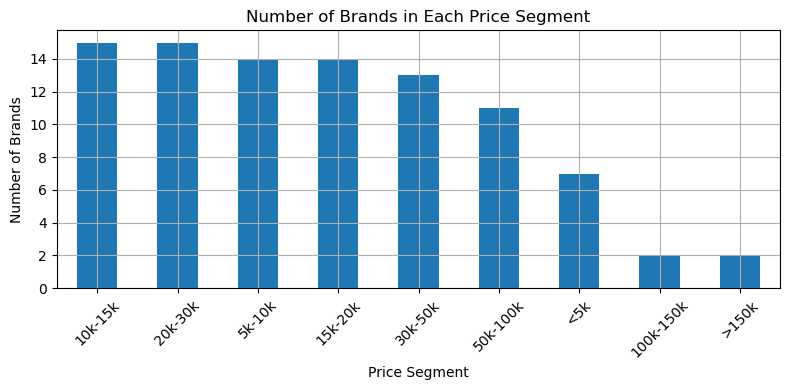

In [52]:
# Which price segment has the most brands competing? Let's see :

segment_brand_counts = combined_df.groupby('Price Segment')['Brand'].nunique().sort_values(ascending=False)
print(segment_brand_counts)

# Visualize
segment_brand_counts.plot(kind='bar', figsize=(8, 4), title='Number of Brands in Each Price Segment')
plt.xlabel('Price Segment')
plt.ylabel('Number of Brands')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

## Top 2 Price Segments are "10k-20k" & "20k-30k"

#### ----------------------------------------------

#### 3) Brand vs Average Rating :

Brand
Google Pixel    4.507018
IQOO            4.400000
POCO            4.388000
vivo            4.324516
Infinix         4.276000
OPPO            4.210582
Xiaomi          4.206020
SAMSUNG         4.160069
Apple           4.117318
Motorola        4.077500
realme          4.074365
ASUS            4.035294
HTC             3.976667
LG              3.958989
Lenovo          3.955111
Nokia           3.854396
GIONEE          3.828085
Name: Rating, dtype: float64


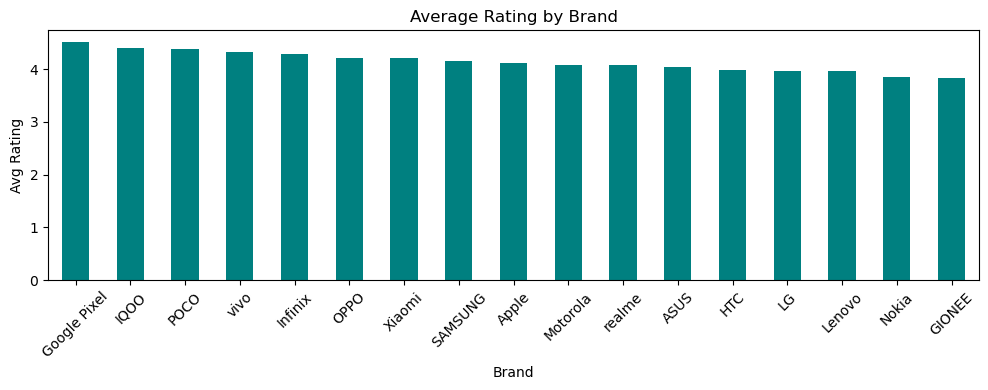

In [53]:
# Which brands consistently get good ratings? Let's see :

avg_rating_by_brand = combined_df.groupby('Brand')['Rating'].mean().sort_values(ascending=False)
print(avg_rating_by_brand)

# Visualize
avg_rating_by_brand.plot(kind='bar', figsize=(10, 4), title='Average Rating by Brand', color='teal')
plt.ylabel('Avg Rating')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Average Rating is almost same for all the Brands in Mobile Market

#### -----------------------------------

#### 4) Memory(RAM) / Storage combos :

In [54]:
# Which Memory(RAM) /Storage combos are most preferred? Let's See : 

top_combos = combined_df.groupby(['Memory', 'Storage']).size().reset_index(name='Count').sort_values('Count', ascending=False).head(10)
print(top_combos)

    Memory Storage  Count
75    4 GB   64 GB    802
56    3 GB   32 GB    555
104   6 GB  128 GB    430
38    2 GB   16 GB    353
121   8 GB  128 GB    314
9     1 GB    8 GB    204
41    2 GB   32 GB    190
110   6 GB   64 GB    189
70    4 GB  128 GB    167
73    4 GB   32 GB    124


### Top Combos are (Memory/Storage) = 4GB/64GB , 3GB/32GB, 6GB/128GB

# =================================================

### For Final Report, Kindly Go Through The Presentation in same Folder

# THANK YOU ...!!!